# Hyperparameter Tuning Using Ray Tune & Optuna

In [28]:
import pandas as pd
import numpy as np
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch
import torch.nn as nn
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
from torchinfo import summary
from torch.utils.tensorboard import SummaryWriter
import os
from datetime import datetime
# counter
from collections import Counter

from notifier import send_notification, send_image, send_email
import time
from typing import Dict, Optional, Any

import ray
from ray import tune
from ray.tune.search import ConcurrencyLimiter
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler
from ray.train import Checkpoint

In [29]:
writer = SummaryWriter()

In [30]:
with open('../data/processed/dataset.pkl', 'rb') as f:
    dataset = pickle.load(f)

In [31]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device

'mps'

In [32]:
dataset.keys()

dict_keys(['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'X_train_store_category_le', 'X_val_store_category_le', 'X_test_store_category_le', 'y_scaler', 'X_scaler'])

In [33]:
X_train = dataset['X_train'].drop(columns=["store_primary_category"], axis=1)
y_train = dataset['y_train']
X_test = dataset['X_test'].drop(columns=["store_primary_category"], axis=1)
y_test = dataset['y_test']
X_val = dataset['X_val'].drop(columns=["store_primary_category"], axis=1)
y_val = dataset['y_val']
X_train_store_category_le=dataset['X_train_store_category_le']
X_val_store_category_le=dataset['X_val_store_category_le']
X_test_store_category_le=dataset['X_test_store_category_le']
y_scaler = dataset['y_scaler']

In [34]:
len(X_train_store_category_le.unique())

66

In [35]:
X_train

,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,created_at_day,created_at_week_of_month,...,order_protocol_4,order_protocol_5,order_protocol_6,order_protocol_7,market_id_1.0,market_id_2.0,market_id_3.0,market_id_4.0,market_id_5.0,market_id_6.0
0,-1.476124,-0.871722,-1.034172,1.240675,0.392978,0.571490,0.039174,0.245421,-1.134736,-1.239225,...,-0.328042,-0.551125,-0.055785,-0.010236,1.988032,-0.669426,-0.361982,-0.604066,-0.336386,-0.061526
1,0.681610,1.087606,0.203869,0.035185,0.619776,-0.899030,-0.793534,-0.574043,0.050511,0.223960,...,-0.328042,-0.551125,-0.055785,-0.010236,-0.503010,-0.669426,-0.361982,-0.604066,2.972779,-0.061526
2,1.028928,0.803999,0.822890,-0.639393,0.207957,-1.084102,-1.116101,-1.149366,0.912508,0.955552,...,-0.328042,-0.551125,-0.055785,-0.010236,1.988032,-0.669426,-0.361982,-0.604066,-0.336386,-0.061526
3,0.233840,-2.096527,0.203869,-1.813373,-3.179565,-0.957729,-1.116101,-1.149366,0.697009,0.955552,...,3.048392,-0.551125,-0.055785,-0.010236,1.988032,-0.669426,-0.361982,-0.604066,-0.336386,-0.061526
4,1.760477,1.615537,2.060932,-1.485583,-0.184935,1.103979,0.918815,1.122582,1.666756,1.687144,...,-0.328042,-0.551125,-0.055785,-0.010236,-0.503010,-0.669426,-0.361982,-0.604066,-0.336386,16.253271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124094,0.233840,-0.135710,0.203869,0.035185,-0.907514,0.007581,-0.684828,-0.507158,1.451257,1.687144,...,-0.328042,-0.551125,-0.055785,-0.010236,-0.503010,-0.669426,-0.361982,1.655449,-0.336386,-0.061526
124095,-0.397257,-0.685361,-0.415151,0.244151,-0.657713,1.410517,1.457125,1.908377,1.666756,1.687144,...,-0.328042,1.814470,-0.055785,-0.010236,-0.503010,1.493818,-0.361982,-0.604066,-0.336386,-0.061526
124096,1.028928,1.715097,1.441911,-0.639393,1.370725,0.771101,0.814776,0.860472,1.235757,0.955552,...,-0.328042,-0.551125,-0.055785,-0.010236,-0.503010,-0.669426,-0.361982,1.655449,-0.336386,-0.061526
124097,0.233840,-0.344915,0.203869,-0.497905,-0.583804,0.129015,-0.241273,-0.383404,0.589259,0.223960,...,-0.328042,1.814470,-0.055785,-0.010236,-0.503010,-0.669426,-0.361982,1.655449,-0.336386,-0.061526


In [36]:
class CustomDataset(Dataset):
    def __init__(self, X, y, category):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long).unsqueeze(1)
        self.category = torch.tensor(category.values, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.category[idx]
    
train_dataset = CustomDataset(X_train, y_train, X_train_store_category_le)
val_dataset = CustomDataset(X_val, y_val, X_val_store_category_le)
test_dataset = CustomDataset(X_test, y_test, X_test_store_category_le)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [37]:
for X_batch, y_batch, category_batch in val_loader:
    print(f'X_batch shape: {X_batch.shape}, y_batch shape: {y_batch.shape}, category_batch shape: {category_batch.shape}')
    break

X_batch shape: torch.Size([64, 31]), y_batch shape: torch.Size([64, 1]), category_batch shape: torch.Size([64])


In [38]:
class Trainer:
    def __init__(self, model, criterion, optimizer, log_dir=None, checkpoint_dir=None):
        self.model = model.to(device)
        self.criterion = criterion
        self.optimizer = optimizer
        self.plotting_dict = {
            "train_loss": [],
            "val_loss": [],
        }
        self.early_stop_counter = 0
        self.early_stop_patience = 5
        self.best_val_loss = float('inf')
        self.checkpoint_dir = checkpoint_dir
        
        # TensorBoard setup
        if log_dir is None:
            current_time = datetime.now().strftime('%Y%m%d-%H%M%S')
            log_dir = os.path.join('runs', current_time)
        
        self.writer = SummaryWriter(log_dir)
    
    def train(self, train_dataloader, val_dataloader, epochs=5, checkpoint_path=None):
        self.model.train()
        dataset_size = len(train_dataloader)
        
        # Create a temporary directory for checkpoints if not provided
        temp_checkpoint_dir = self.checkpoint_dir
        if temp_checkpoint_dir is None:
            temp_checkpoint_dir = os.path.abspath(os.path.join(os.getcwd(), 'ray_results'))
            os.makedirs(temp_checkpoint_dir, exist_ok=True)
        
        # Try to load checkpoint if exists
        checkpoint = ray.train.get_checkpoint()
        if checkpoint:
            with checkpoint.as_directory() as checkpoint_dir:
                print(f"Loading checkpoint from {checkpoint_dir}")
                checkpoint_dict = torch.load(os.path.join(checkpoint_dir, "checkpoint.pt"))
                start = checkpoint_dict["epoch"] + 1
                self.model.load_state_dict(checkpoint_dict["model_state"])
        
        for epoch in range(epochs):
            total_loss = 0
            for i, (inputs, targets, category) in enumerate(train_dataloader):
                inputs, targets, category = inputs.to(device), targets.to(device), category.to(device)
                
                outputs = self.model(inputs, category)
                loss = self.criterion(outputs, targets.float())
                loss.backward()
                self.optimizer.step()
                self.optimizer.zero_grad()
                
                total_loss += loss.item()
                
                if i % 10 == 0: 
                    step = epoch * len(train_dataloader) + i
                    self.writer.add_scalar('Batch/Loss', loss.item(), step)
            
            individual_loss = total_loss / dataset_size
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {individual_loss:.4f}")
            
            val_loss = self.evaluate(val_dataloader, "Validation")
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.early_stop_counter = 0
                
                # Save model checkpoint
                print(f"Validation loss improved to {val_loss:.4f}. Saving model...")
                checkpoint_path = os.path.join(temp_checkpoint_dir, "checkpoint.pt")
                torch.save({
                    "epoch": epoch,
                    "model_state": self.model.state_dict(),
                    "optimizer_state": self.optimizer.state_dict(),
                    "val_loss": val_loss
                }, checkpoint_path)
            else:
                self.early_stop_counter += 1
                if self.early_stop_counter >= self.early_stop_patience:
                    print(f"Early stopping at epoch {epoch}")
                    break
            
            self.plotting_dict["train_loss"].append(individual_loss)
            self.plotting_dict["val_loss"].append(val_loss)
            
            self.writer.add_scalar('Loss/Train', individual_loss, epoch)
            self.writer.add_scalar('Loss/Validation', val_loss, epoch)
            
            for name, param in self.model.named_parameters():
                self.writer.add_histogram(f'Parameters/{name}', param, epoch)
        
        # Create checkpoint and report metrics
        try:
            print("Reporting metrics and checkpoint...")
            checkpoint = ray.train.Checkpoint.from_directory(temp_checkpoint_dir)
            ray.train.report({"val_loss": val_loss}, checkpoint=checkpoint)
        except Exception as e:
            print(f"Warning: Failed to report checkpoint: {e}")
            # Fallback to just reporting metrics without checkpoint
            try:
                ray.train.report({"val_loss": val_loss})
            except Exception as e:
                print(f"Warning: Failed to report metrics: {e}")
        
        return val_loss
            
    def evaluate(self, dataloader, mode="Evaluation"):
        self.model.eval()
        loss = 0
        with torch.no_grad():
            for inputs, targets, category in dataloader:
                inputs, targets, category = inputs.to(device), targets.to(device), category.to(device)
                outputs = self.model(inputs, category)
                loss += self.criterion(outputs, targets.float()).item()
        loss /= len(dataloader)
        print(f"{mode} Loss: {loss:.4f}")
        print("-------------------------")

        return loss
    
    def plot(self):
        fig = plt.figure(figsize=(10, 6))
        plt.plot(self.plotting_dict["train_loss"], label="Train Loss")
        plt.plot(self.plotting_dict["val_loss"], label="Validation Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()
        plt.tight_layout()
        
        # self.writer.add_figure('Loss Curves', fig)
        
        return fig
    
    def close(self):
        """Close the TensorBoard writer when done"""
        self.writer.close()

    def save_checkpoint(self, epoch, val_loss):
        if not self.checkpoint_dir:
            return

        checkpoint_path = os.path.join(self.checkpoint_dir, f"checkpoint_epoch_{epoch}.pt")
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "val_loss": val_loss,
        }
        torch.save(checkpoint, checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")

    def load_checkpoint(self, checkpoint_path):
        if not os.path.exists(checkpoint_path):
            print(f"No checkpoint found at {checkpoint_path}")
            return

        checkpoint = torch.load(checkpoint_path, map_location=device)
        self.model.load_state_dict(checkpoint["model_state_dict"])
        self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        self.best_val_loss = checkpoint["val_loss"]
        print(f"Checkpoint loaded from {checkpoint_path}")

In [39]:
class NetworkWithCategoryEmbedding(nn.Module):
    def __init__(self, input_size, num_categories, embedding_dim, 
                 neuron_counts=[128, 128, 64, 32], 
                 activation_fn=torch.tanh):
        super().__init__()
        self.category_embedding = nn.Embedding(num_categories, embedding_dim)
        self.batchnorm_emb = nn.BatchNorm1d(embedding_dim)
        
        self.fc1 = nn.Linear(input_size, neuron_counts[0])
        self.fc2 = nn.Linear(neuron_counts[0] + embedding_dim, neuron_counts[1])
        self.fc3 = nn.Linear(neuron_counts[1], neuron_counts[2])
        self.fc4 = nn.Linear(neuron_counts[2], neuron_counts[3])
        self.fc5 = nn.Linear(neuron_counts[3], 1)
        self.dropout = nn.Dropout(0.2)
        
        self.activation = activation_fn
       
    def forward(self, x, categories):
        emb = self.batchnorm_emb(self.category_embedding(categories))
        x = self.activation(self.fc1(x))
        x = torch.cat((x, emb), dim=1)
        x = self.activation(self.fc2(x))
        x = self.activation(self.fc3(x))
        x = self.dropout(x) 
        x = self.activation(self.fc4(x))
        x = self.fc5(x)
        return x

In [40]:
def objective(config):
    
    activation_map = {
        "tanh": torch.tanh,
        "relu": torch.relu,
        "leaky_relu": nn.functional.leaky_relu,
        "elu": nn.functional.elu
    }
    
    activation_fn = activation_map[config["activation"]]
    
    neuron_counts = [
        config["layer1_neurons"],
        config["layer2_neurons"],
        config["layer3_neurons"],
        config["layer4_neurons"]
    ]
    
    model = NetworkWithCategoryEmbedding(
        input_size=X_train.shape[1],
        num_categories=len(X_train_store_category_le.unique()),
        embedding_dim=35,
        neuron_counts=neuron_counts,
        activation_fn=activation_fn,
    ) 

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    
    tunerTrainer = Trainer(
        model,
        loss_fn,
        optimizer,
        # checkpoint_path=tune.get_checkpoint_dir(),
    )

    val_loss = tunerTrainer.train(
        train_loader,
        val_loader,
        epochs=10,
        # checkpoint_path=tune.get_checkpoint_dir(),
    )
    
    # ray.train.report(dict(val_loss=val_loss))



In [41]:
def run_optuna_optimization():
    # Define search space
    search_space = {
       
        # Neuron counts
        "layer1_neurons": tune.choice([64, 128, 256]),
        "layer2_neurons": tune.choice([64, 128, 256]),
        "layer3_neurons": tune.choice([32, 64, 128]),
        "layer4_neurons": tune.choice([16, 32, 64]),
        
        "activation": tune.choice(["tanh", "relu", "leaky_relu", "elu"])
    }
    
    optuna_search = OptunaSearch(
        metric="val_loss",
        mode="min"
    )
    
    scheduler = ASHAScheduler(
        max_t=10,  # Max epochs
        grace_period=5,
        reduction_factor=2,
        metric="val_loss",  
        mode="min"         
    )
    
    tuner = tune.Tuner(
            tune.with_resources(
                objective,
                resources={"cpu": 2}  
            ),
            tune_config=tune.TuneConfig(
            search_alg=optuna_search,
            scheduler=scheduler,
            num_samples=20,  
        ),
            param_space=search_space,
            run_config=ray.train.RunConfig(
                storage_path=os.path.abspath(os.path.join(os.getcwd(), 'ray_results')),
                name="optuna_regression_asha_mps",
                checkpoint_config=ray.train.CheckpointConfig(
                    num_to_keep=1,
                    checkpoint_score_attribute="val_loss",
                    checkpoint_score_order="min",
                ),
            ),
        )
    
    results = tuner.fit()
    return results

In [42]:
def get_best_model_from_tuning(results):
    # Get the best trial
    # best_result = results.get_best_result(metric="val_loss", mode="min")
    best_config = results.get_best_config(metric="val_loss", mode="min")
    best_trial = results.get_best_trial(metric="val_loss", mode="min")
    
    # print(f"Best trial config: {best_result.config}")
    # print(f"Best trial final validation loss: {best_result.metrics['val_loss']}")
    
    # Get the best model hyperparameters
    # best_config = best_result.config
    
    # Create a model with the best hyperparameters
    activation_map = {
        "relu": nn.ReLU(),
        "tanh": nn.Tanh(),
        "leaky_relu": nn.LeakyReLU(),
        "elu": nn.ELU()
    }
    
    best_model = NetworkWithCategoryEmbedding(
        input_size=X_train.shape[1],
        num_categories=len(X_train_store_category_le.unique()),
        embedding_dim=35,
        neuron_counts=[
            best_config["layer1_neurons"],
            best_config["layer2_neurons"],
            best_config["layer3_neurons"],
            best_config["layer4_neurons"]
        ],
        activation_fn=activation_map[best_config["activation"]],
    ).to(device)
    
    # Load the model weights from the checkpoint
    checkpoint_path = results.get_best_checkpoint(best_trial, metric="val_loss", mode="min").to_directory()
    checkpoint = torch.load(os.path.join(checkpoint_path, "checkpoint.pt"), map_location=device)
    best_model.load_state_dict(checkpoint["model_state"])
    
    return best_model, best_config

In [43]:
results = run_optuna_optimization()
send_notification("Tuning finished")

(raylet) Warning: The actor ImplicitFunc is very large (52 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.
(objective pid=12963) Epoch [1/10], Loss: 0.3953
(objective pid=12963) Validation Loss: 0.3811
(objective pid=12963) -------------------------
(objective pid=12963) Validation loss improved to 0.3811. Saving model...
(objective pid=12972) Epoch [1/10], Loss: 0.3978 [repeated 3x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(objective pid=12971) Validation Loss: 0.3814 [repeated 2x across cluster]
(objective pid=12971) ------------------------- [repeated 2x across cluster]
(objective pid=12971) Validation loss improved to 0.3814. Saving model... [repeated 2x across cluster]
(objective pi

2025-03-20 02:46:07,398	WARNING experiment_state.py:206 -- Experiment state snapshotting has been triggered multiple times in the last 5.0 seconds and may become a bottleneck. A snapshot is forced if `CheckpointConfig(num_to_keep)` is set, and a trial has checkpointed >= `num_to_keep` times since the last snapshot.
You may want to consider increasing the `CheckpointConfig(num_to_keep)` or decreasing the frequency of saving checkpoints.
You can suppress this warning by setting the environment variable TUNE_WARN_EXCESSIVE_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S to a smaller value than the current threshold (5.0). Set it to 0 to completely suppress this warning.
(objective pid=12963) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/gautamnaik/Developer/ai/PorterDeepLearningCaseStudy/notebooks/ray_results/optuna_regression_asha_mps/objective_afb74d73_1_activation=leaky_relu,layer1_neurons=256,layer2_neurons=128,layer3_neurons=32,layer4_neurons=64_2025-03-20_02-44

(objective pid=12963) Reporting metrics and checkpoint...


2025-03-20 02:46:08,142	WARNING experiment_state.py:206 -- Experiment state snapshotting has been triggered multiple times in the last 5.0 seconds and may become a bottleneck. A snapshot is forced if `CheckpointConfig(num_to_keep)` is set, and a trial has checkpointed >= `num_to_keep` times since the last snapshot.
You may want to consider increasing the `CheckpointConfig(num_to_keep)` or decreasing the frequency of saving checkpoints.
You can suppress this warning by setting the environment variable TUNE_WARN_EXCESSIVE_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S to a smaller value than the current threshold (5.0). Set it to 0 to completely suppress this warning.


(objective pid=12970) Early stopping at epoch 9


...

2025-03-20 02:49:08,615	WARNING experiment_state.py:206 -- Experiment state snapshotting has been triggered multiple times in the last 5.0 seconds and may become a bottleneck. A snapshot is forced if `CheckpointConfig(num_to_keep)` is set, and a trial has checkpointed >= `num_to_keep` times since the last snapshot.
You may want to consider increasing the `CheckpointConfig(num_to_keep)` or decreasing the frequency of saving checkpoints.
You can suppress this warning by setting the environment variable TUNE_WARN_EXCESSIVE_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S to a smaller value than the current threshold (5.0). Set it to 0 to completely suppress this warning.
(objective pid=13084) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/gautamnaik/Developer/ai/PorterDeepLearningCaseStudy/notebooks/ray_results/optuna_regression_asha_mps/objective_95437429_18_activation=tanh,layer1_neurons=128,layer2_neurons=64,layer3_neurons=64,layer4_neurons=64_2025-03-20_02-47-44/ch

(objective pid=13084) Reporting metrics and checkpoint...
(objective pid=13081) Epoch [10/10], Loss: 0.3458 [repeated 2x across cluster]
(objective pid=13084) Validation Loss: 0.3654 [repeated 2x across cluster]
(objective pid=13084) ------------------------- [repeated 2x across cluster]


2025-03-20 02:49:11,962	WARNING experiment_state.py:206 -- Experiment state snapshotting has been triggered multiple times in the last 5.0 seconds and may become a bottleneck. A snapshot is forced if `CheckpointConfig(num_to_keep)` is set, and a trial has checkpointed >= `num_to_keep` times since the last snapshot.
You may want to consider increasing the `CheckpointConfig(num_to_keep)` or decreasing the frequency of saving checkpoints.
You can suppress this warning by setting the environment variable TUNE_WARN_EXCESSIVE_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S to a smaller value than the current threshold (5.0). Set it to 0 to completely suppress this warning.
(objective pid=13081) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/Users/gautamnaik/Developer/ai/PorterDeepLearningCaseStudy/notebooks/ray_results/optuna_regression_asha_mps/objective_b2833c25_17_activation=relu,layer1_neurons=256,layer2_neurons=64,layer3_neurons=64,layer4_neurons=16_2025-03-20_02-46-25/ch

(objective pid=13085) Validation loss improved to 0.3600. Saving model...
(objective pid=13085) Reporting metrics and checkpoint... [repeated 2x across cluster]


2025-03-20 02:49:14,707	WARNING experiment_state.py:206 -- Experiment state snapshotting has been triggered multiple times in the last 5.0 seconds and may become a bottleneck. A snapshot is forced if `CheckpointConfig(num_to_keep)` is set, and a trial has checkpointed >= `num_to_keep` times since the last snapshot.
You may want to consider increasing the `CheckpointConfig(num_to_keep)` or decreasing the frequency of saving checkpoints.
You can suppress this warning by setting the environment variable TUNE_WARN_EXCESSIVE_EXPERIMENT_CHECKPOINT_SYNC_THRESHOLD_S to a smaller value than the current threshold (5.0). Set it to 0 to completely suppress this warning.
2025-03-20 02:49:14,716	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/Users/gautamnaik/Developer/ai/PorterDeepLearningCaseStudy/notebooks/ray_results/optuna_regression_asha_mps' in 0.0061s.
2025-03-20 02:49:14,719	INFO tune.py:1041 -- Total run time: 281.63 seconds (281.50 seconds for t

In [44]:
best_result = results.get_best_result(metric="val_loss", mode="min")
best_config = best_result.config
best_config

{'layer1_neurons': 256,
 'layer2_neurons': 128,
 'layer3_neurons': 32,
 'layer4_neurons': 64,
 'activation': 'elu'}

In [45]:
results.get_best_result(metric="val_loss", mode="min").metrics

{'val_loss': 0.35998701601504135,
 'timestamp': 1742419152,
 'checkpoint_dir_name': 'checkpoint_000000',
 'should_checkpoint': True,
 'done': True,
 'training_iteration': 1,
 'trial_id': '577065fa',
 'date': '2025-03-20_02-49-12',
 'time_this_iter_s': 82.945809841156,
 'time_total_s': 82.945809841156,
 'pid': 13085,
 'hostname': 'Gautams-MacBook-Pro.local',
 'node_ip': '127.0.0.1',
 'config': {'layer1_neurons': 256,
  'layer2_neurons': 128,
  'layer3_neurons': 32,
  'layer4_neurons': 64,
  'activation': 'elu'},
 'time_since_restore': 82.945809841156,
 'iterations_since_restore': 1,
 'experiment_tag': '19_activation=elu,layer1_neurons=256,layer2_neurons=128,layer3_neurons=32,layer4_neurons=64'}

In [48]:
def load_previous_tuning_results():
    from ray.tune import ExperimentAnalysis
    
    # Path to your stored results (adjust if needed)
    results_path = os.path.abspath(os.path.join(os.getcwd(), 'ray_results', 'optuna_regression_asha_mps'))
    
    # Check if the directory exists
    if not os.path.exists(results_path):
        print(f"No results found at {results_path}")
        return None
    
    # Load the experiment analysis
    analysis = ExperimentAnalysis(results_path)
    print(f"Loaded results from {results_path}")
    print(f"Number of trials: {len(analysis.trials)}")
    
    return analysis

# Load previous results
results = load_previous_tuning_results()

if results is not None:
    best_config = results.get_best_config(metric="val_loss", mode="min")
    best_trial = results.get_best_trial(metric="val_loss", mode="min")
    # get the best model
    # best_model = get_best_model_from_tuning(results)
    
    print("Best hyperparameters found:")
    print(best_config)
    print(f"Best validation loss: {best_trial.last_result['val_loss']}")

Loaded results from /Users/gautamnaik/Developer/ai/PorterDeepLearningCaseStudy/notebooks/ray_results/optuna_regression_asha_mps
Number of trials: 20
Best hyperparameters found:
{'layer1_neurons': 256, 'layer2_neurons': 128, 'layer3_neurons': 32, 'layer4_neurons': 64, 'activation': 'elu'}
Best validation loss: 0.35998701601504135


In [49]:
best_model, best_config = get_best_model_from_tuning(results)

In [50]:
# You can now use the best model for inference
best_model.eval()
predictions = []
with torch.no_grad():
    for X_batch, y_batch, category_batch in test_loader:
        X_batch, y_batch, category_batch = X_batch.to(device), y_batch.to(device), category_batch.to(device)
        preds = best_model(X_batch, category_batch)
        predictions.append(preds)
predictions = torch.cat(predictions).cpu().numpy()


In [51]:
y_test.shape, predictions.shape

((26593,), (26593, 1))

In [52]:
# inverse the scaling
y_test_o = np.power(y_scaler.inverse_transform(y_test.to_frame()), 3)
predictions_o = np.power(y_scaler.inverse_transform(predictions), 3)

In [53]:
# mean squared error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test_o, predictions_o)
mae = mean_absolute_error(y_test_o, predictions_o)
r2 = r2_score(y_test_o, predictions_o)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

MSE: 242.7666
MAE: 11.3193
R2: 0.2495


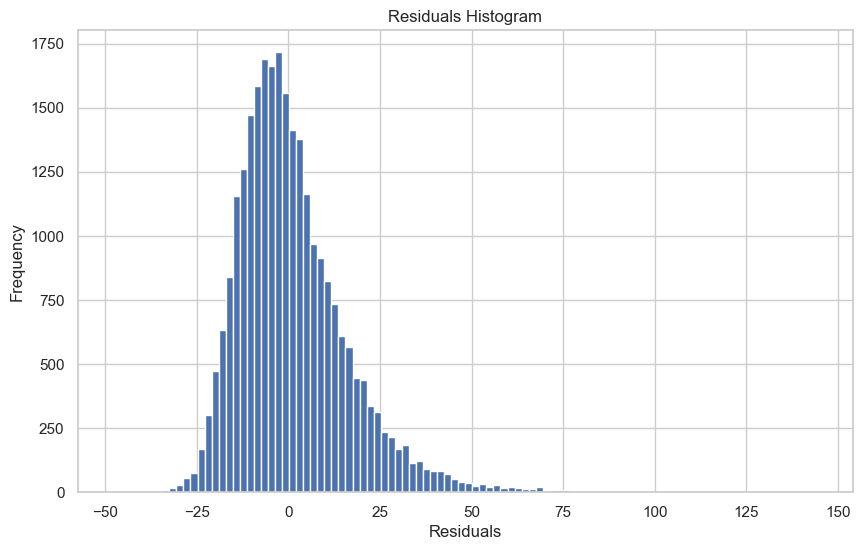

In [54]:
residuals = y_test_o - predictions_o
residuals = residuals.flatten()
residuals.shape
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=100)
plt.title("Residuals Histogram")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

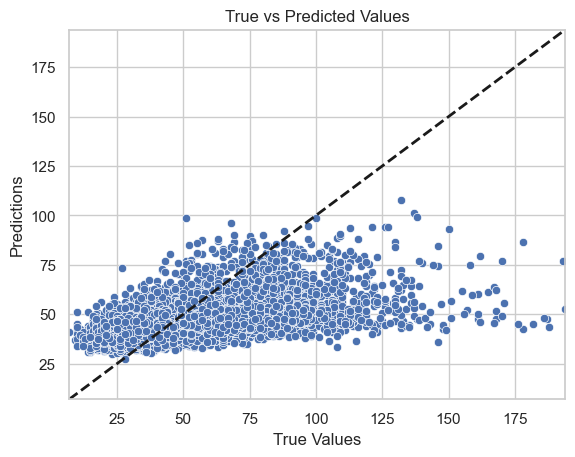

In [55]:
sns.scatterplot(x=y_test_o.flatten(), y=predictions_o.flatten())
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True vs Predicted Values")
plt.plot([y_test_o.min(), y_test_o.max()], [y_test_o.min(), y_test_o.max()], 'k--', lw=2)
plt.xlim(y_test_o.min(), y_test_o.max())
plt.ylim(y_test_o.min(), y_test_o.max())
plt.show()